In [1169]:
import pytweezer.phasemask as pm
import pytweezer.communication as com
from pytweezer.experiment import motmaster_client
from pytweezer.analysis import analysis as pyt
from pytweezer.drivers.imagemX2 import ImagEMX2CameraClient, ImagEMX2Camera
from pytweezer.drivers import anapico
import matplotlib.pyplot as plt
import numpy as np
from time import sleep
import sys
from rich.progress import track
from scipy.signal import savgol_filter

texp = pyt.TweezerExperimentAnalysis(day='23',month='04Apr', year='2026')
exp = motmaster_client.MotMasterClient("Rb")
SLM = com.SLMClient()

---- 23/04Apr/202026 Tweezer Experiment Analysis Initialised ----


In [2]:
local_cam = ImagEMX2Camera()

In [1170]:
local_cam.reacquire_camera()

{'ok': True, 'relinquished': False}

In [1171]:
# Camera configuration
import time

local_cam.set_trigger_source("ext")
local_cam.set_external_exposure_mode()
local_cam.enable_em_gain(True)
local_cam.enable_direct_em_gain(True)
local_cam.set_sensitivity(1200)
local_cam.timeout = 60*2
X0, Y0, WIDTH, HEIGHT = 50, 70, 384, 384
local_cam.set_roi(X0, WIDTH, Y0, HEIGHT)

In [1172]:
def rotate_positions(x_n, y_n, angle_degrees):
    angle_radians = np.radians(angle_degrees)
    cos_angle = np.cos(angle_radians)
    sin_angle = np.sin(angle_radians)
    
    x_rotated = cos_angle * x_n - sin_angle * y_n
    y_rotated = sin_angle * x_n + cos_angle * y_n
    
    return x_rotated, y_rotated

PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(46.50, 10.54),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (46.5, 10.54) um


---
## Generate Initial Phasemask

In [1173]:
W = np.ones((9, 9))
spacing_um = 5

target1 = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
_, terms1, _ = PM.superposition_optimization(target1, max_iter=1000, damping=0.5, verbose=True)
w_n, theta_n, x_n, y_n, array_shape = terms1
pm_array1 = PM.generate_phasemask(terms1)

--- Target Generation ---
Grid: 9x9
Spacing: 5 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 2.71e-05 | Uniformity: 57.82% | Min/Max ratio: 0.095
Iteration 010 | Mean-Squared Error: 1.88e-07 | Uniformity: 96.48% | Min/Max ratio: 0.839
Iteration 020 | Mean-Squared Error: 6.55e-08 | Uniformity: 97.93% | Min/Max ratio: 0.902
Iteration 030 | Mean-Squared Error: 1.11e-08 | Uniformity: 99.15% | Min/Max ratio: 0.962
Iteration 040 | Mean-Squared Error: 2.03e-08 | Uniformity: 98.85% | Min/Max ratio: 0.949
Iteration 050 | Mean-Squared Error: 3.35e-08 | Uniformity: 98.52% | Min/Max ratio: 0.930
Iteration 060 | Mean-Squared Error: 8.51e-09 | Uniformity: 99.25% | Min/Max ratio: 0.964
Iteration 070 | Mean-Squared Error: 5.54e-09 | Uniformity: 99.40% | Min/Max ratio: 0.960
Iteration 080 | Mean-Squared Error: 8.22e-09 | Uniformity: 99.27% | Min/Max ratio: 0.965
Iteration 090 | Mean-Squared Error: 3.76e-09 | Uniformity: 99.50% | Min/Max ratio: 0.975
Iteration

## Generate Final Phasemask

In [1311]:
W = np.ones((5, 5))
spacing_um = 5

target2 = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
_, terms2, _ = PM.superposition_optimization(target2, max_iter=1000, damping=0.5, verbose=True)
w_n, theta_n, x_n, y_n, array_shape = terms2
pm_array2 = PM.generate_phasemask(terms2)

--- Target Generation ---
Grid: 5x5
Spacing: 5 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.75e-04 | Uniformity: 66.94% | Min/Max ratio: 0.175
Iteration 010 | Mean-Squared Error: 1.39e-06 | Uniformity: 97.05% | Min/Max ratio: 0.890
Iteration 020 | Mean-Squared Error: 1.54e-07 | Uniformity: 99.02% | Min/Max ratio: 0.963
Iteration 030 | Mean-Squared Error: 3.08e-07 | Uniformity: 98.61% | Min/Max ratio: 0.946
Iteration 040 | Mean-Squared Error: 6.18e-08 | Uniformity: 99.38% | Min/Max ratio: 0.976
Iteration 050 | Mean-Squared Error: 4.05e-08 | Uniformity: 99.50% | Min/Max ratio: 0.979
Iteration 060 | Mean-Squared Error: 1.72e-07 | Uniformity: 98.96% | Min/Max ratio: 0.960
Iteration 070 | Mean-Squared Error: 2.42e-07 | Uniformity: 98.77% | Min/Max ratio: 0.951
Iteration 080 | Mean-Squared Error: 5.22e-08 | Uniformity: 99.43% | Min/Max ratio: 0.979
Iteration 090 | Mean-Squared Error: 6.74e-08 | Uniformity: 99.35% | Min/Max ratio: 0.974
Iteration

---
## Load Initial Phasemask and Detect Trap Positions

In [1202]:
SLM = com.SLMClient()
pm_init = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_init_uint8 = PM.transform_phase_8bit(pm_init).get()
SLM.update_mask(pm_init_uint8)

{'status': 'success', 'msg': 'Mask updated successfully.'}

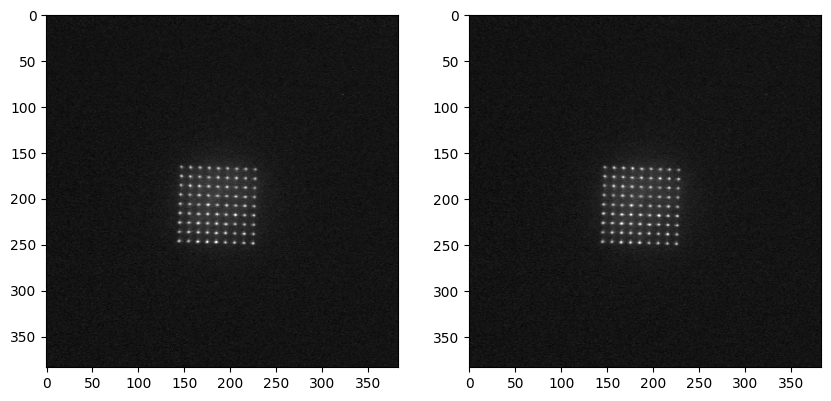

In [633]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_BackgroundSubtracted")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
local_cam.setup_acquisition("snap", n_iterations * 2)
local_cam.start_acquisition()
exp.start_motmaster_experiment({"tImgCool": 0.00, "tImgCoolVVA": 0.43})
imgs = local_cam.acquire_n_frames(n_iterations * 2, timeout = 2*60)
imgs1 = imgs[::2]
imgs2 = imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=True, vmaxfactor=0.8, show_grid=True)

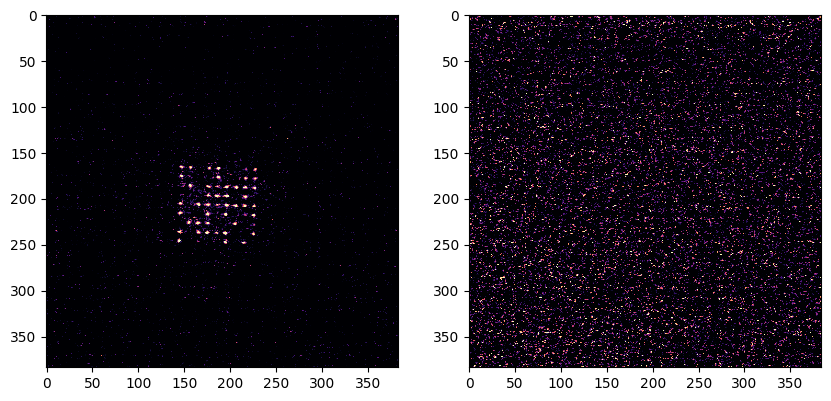

In [717]:
n = 99
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imgs1[n] - img_bg, cmap='magma', vmin=(imgs1[n] - img_bg).max()*0.1, vmax=(imgs1[n] - img_bg).max()*0.4)
axs[1].imshow(imgs2[n] - img_bg, cmap='magma', vmin=(imgs2[n] - img_bg).max()*0.1, vmax=(imgs2[n] - img_bg).max()*0.4)

In [634]:
img_bg = imgs2.mean(axis=0)

Looking for trap sites...
9x9 array detected.


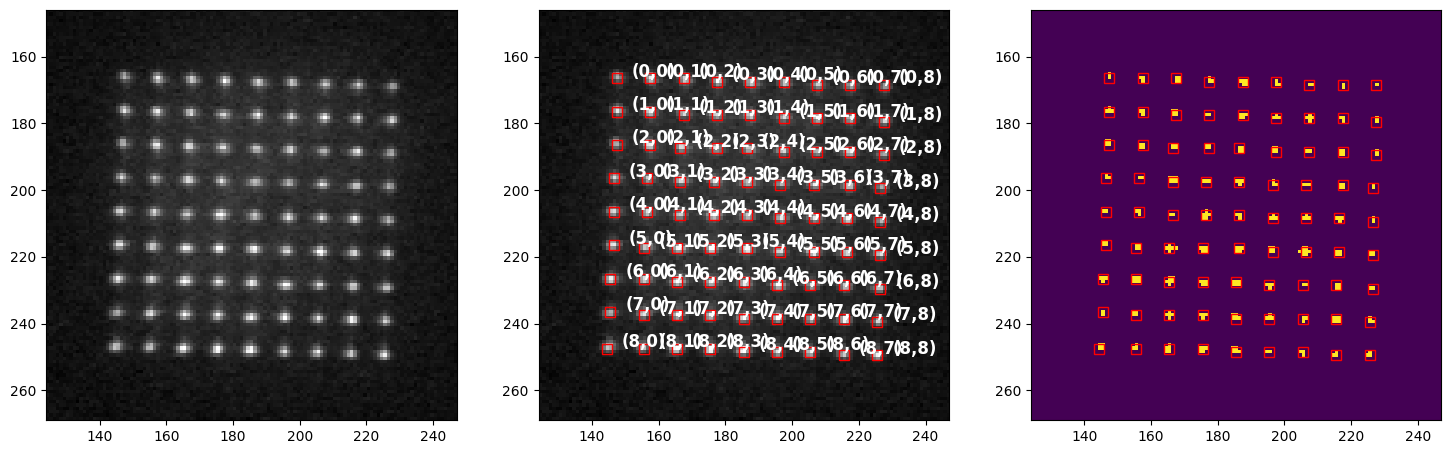

Trap (0, 0) Loading Probability : 51.0 %
Trap (0, 1) Loading Probability : 62.0 %
Trap (0, 2) Loading Probability : 55.00000000000001 %
Trap (0, 3) Loading Probability : 57.99999999999999 %
Trap (0, 4) Loading Probability : 56.99999999999999 %
Trap (0, 5) Loading Probability : 55.00000000000001 %
Trap (0, 6) Loading Probability : 56.00000000000001 %
Trap (0, 7) Loading Probability : 59.0 %
Trap (0, 8) Loading Probability : 48.0 %
Trap (1, 0) Loading Probability : 59.0 %
Trap (1, 1) Loading Probability : 56.99999999999999 %
Trap (1, 2) Loading Probability : 52.0 %
Trap (1, 3) Loading Probability : 51.0 %
Trap (1, 4) Loading Probability : 59.0 %
Trap (1, 5) Loading Probability : 51.0 %
Trap (1, 6) Loading Probability : 62.0 %
Trap (1, 7) Loading Probability : 57.99999999999999 %
Trap (1, 8) Loading Probability : 59.0 %
Trap (2, 0) Loading Probability : 52.0 %
Trap (2, 1) Loading Probability : 63.0 %
Trap (2, 2) Loading Probability : 64.0 %
Trap (2, 3) Loading Probability : 55.00000000000

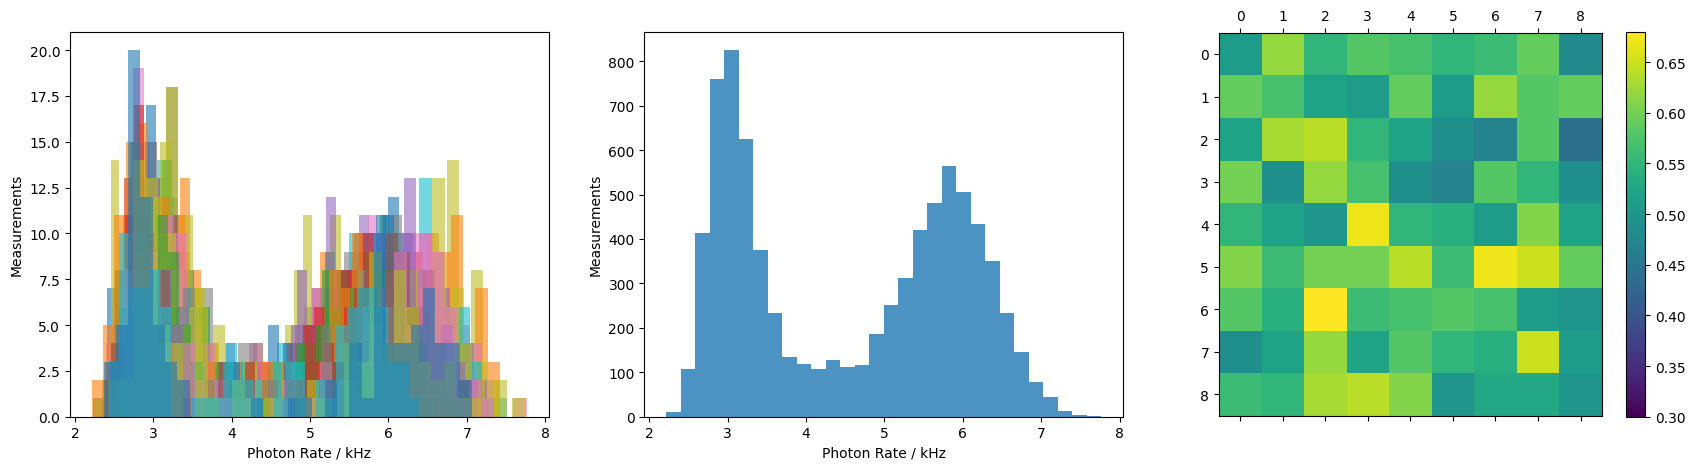

In [635]:
array_shape = [9, 9]
window = 3

grid_positions1, detection_threshold = pyt.detect_trap_sites(img_average, array_shape, detection_step=200)
pyt.visualize_results(img_average, grid_positions1, margin=20, window_size=window, threshold=detection_threshold)
photon_rates, loading_probabilities, threshold = texp.get_array_loading_probability(imgs1, grid_positions1, array_shape, threshold=4., window_size=window, binning=30)

print(f"Loading Threshold = {threshold:.6f} kHz")
print(f"Standard Deviation = {np.std(loading_probabilities) / loading_probabilities.mean()*100} %")
print(f"Average Loading Prob = {loading_probabilities.mean()*100} %")

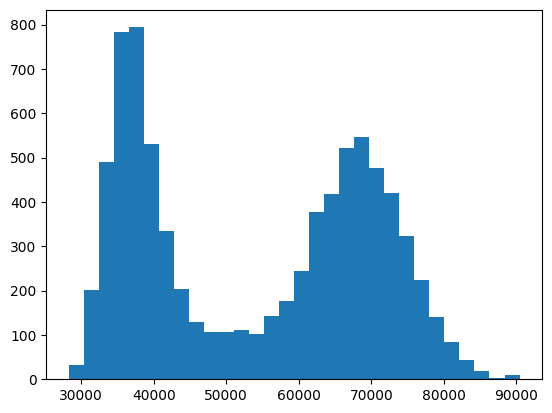

In [490]:
pixel_sums = []
for img in imgs1:
    pixel_sum = pyt.sum_pixel_values(img, grid_positions1, [9,9], window_size=3)
    pixel_sums.append(pixel_sum)
plt.hist(np.array(pixel_sums).flatten(), bins=30)
rn_threshold = 50000

In [446]:
# Experiment and camera setup
n_iterations = 5
exp.set_motmaster_experiment("RbTweezerBasic2026_ImagingSurvivalMeasurement")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
local_cam.setup_acquisition("snap", n_iterations * 2)
local_cam.start_acquisition()
exp.start_motmaster_experiment({"tImgCool": 0.00, "tImgCoolVVA": 0.428})
imgs = local_cam.acquire_n_frames(n_iterations * 2, timeout = 2*60)
imgs1 = imgs[::2]
imgs2 = imgs[1::2]
imgs1_mean = imgs1.mean(axis=0)
imgs2_mean = imgs2.mean(axis=0)

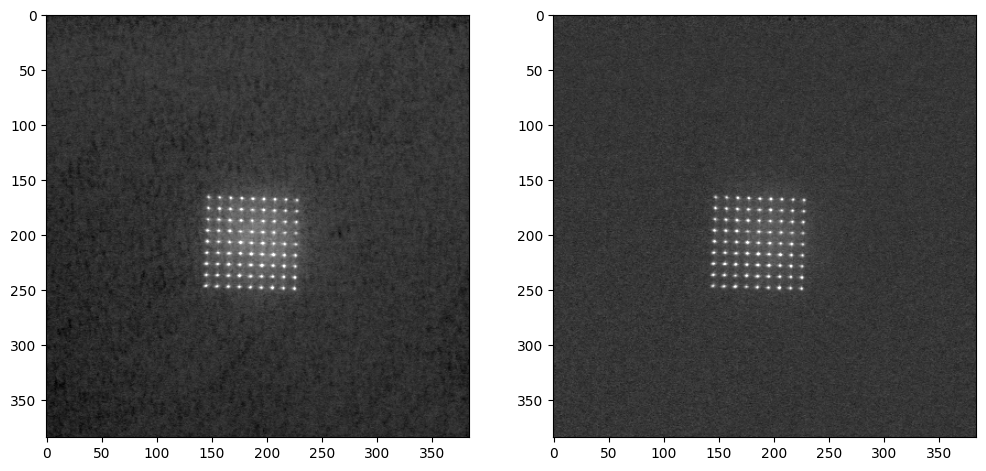

In [440]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow((imgs1_mean - img_bg), cmap='gray', vmax=0.6*(imgs1_mean - img_bg).max())
ax[1].imshow((imgs2_mean - img_bg), cmap='gray', vmax=0.6*(imgs2_mean - img_bg).max())

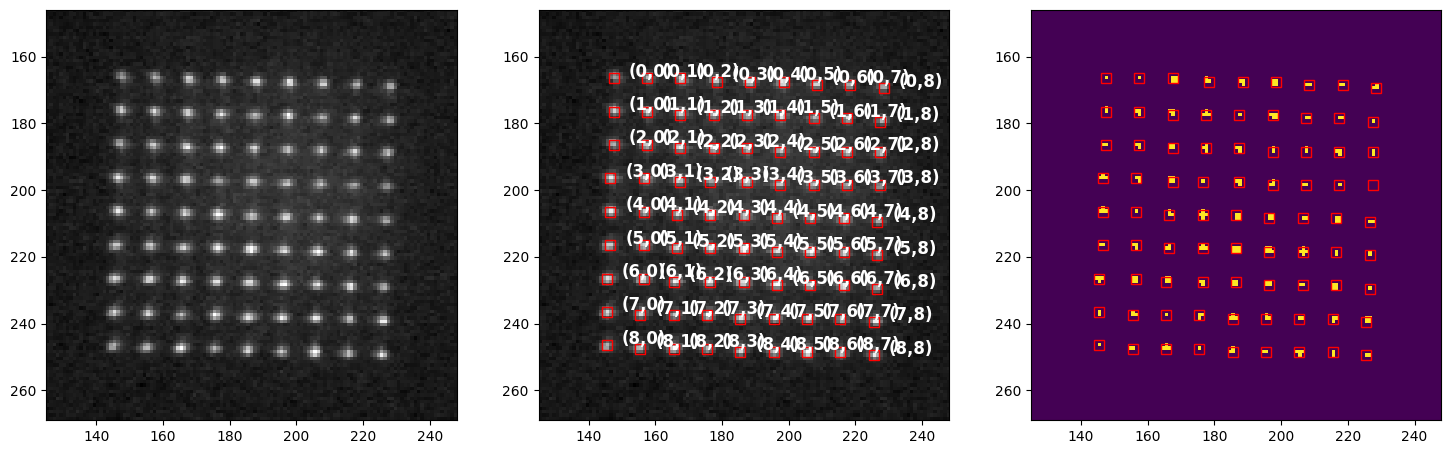

Trap (0, 0) Loading Probability : 45.0 %
Trap (0, 1) Loading Probability : 47.0 %
Trap (0, 2) Loading Probability : 51.0 %
Trap (0, 3) Loading Probability : 54.0 %
Trap (0, 4) Loading Probability : 52.0 %
Trap (0, 5) Loading Probability : 60.0 %
Trap (0, 6) Loading Probability : 49.0 %
Trap (0, 7) Loading Probability : 49.0 %
Trap (0, 8) Loading Probability : 52.0 %
Trap (1, 0) Loading Probability : 55.00000000000001 %
Trap (1, 1) Loading Probability : 50.0 %
Trap (1, 2) Loading Probability : 56.00000000000001 %
Trap (1, 3) Loading Probability : 52.0 %
Trap (1, 4) Loading Probability : 50.0 %
Trap (1, 5) Loading Probability : 56.99999999999999 %
Trap (1, 6) Loading Probability : 42.0 %
Trap (1, 7) Loading Probability : 48.0 %
Trap (1, 8) Loading Probability : 48.0 %
Trap (2, 0) Loading Probability : 45.0 %
Trap (2, 1) Loading Probability : 53.0 %
Trap (2, 2) Loading Probability : 60.0 %
Trap (2, 3) Loading Probability : 57.99999999999999 %
Trap (2, 4) Loading Probability : 48.0 %
Trap 

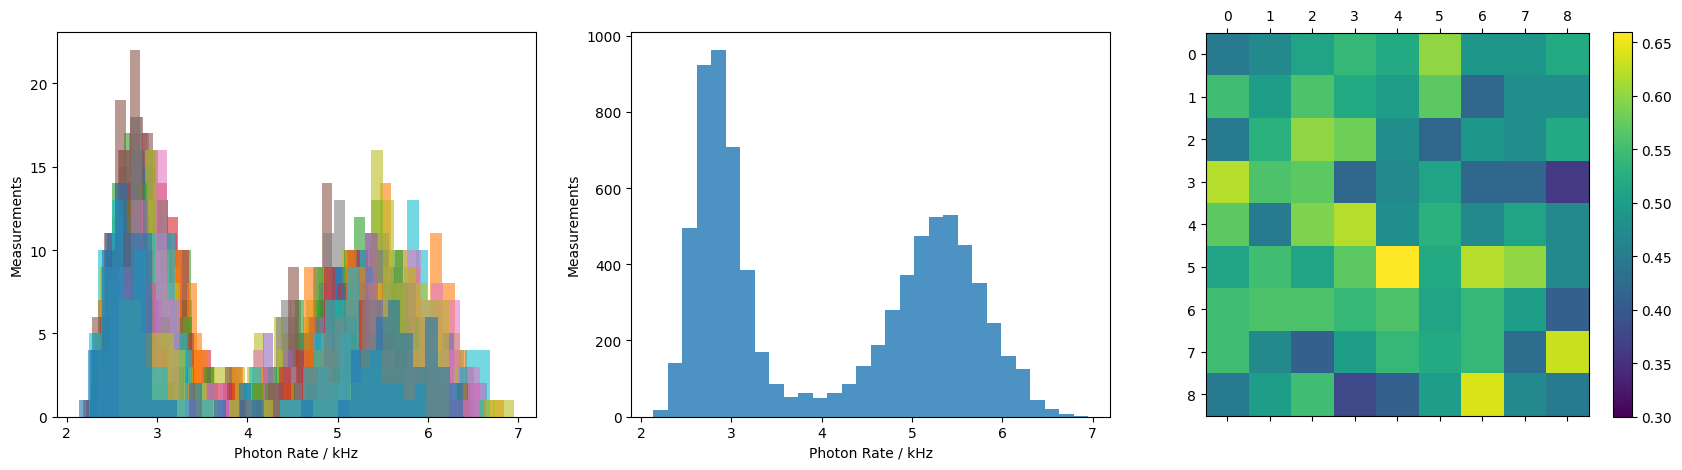

In [443]:
array_shape = [9, 9]
window = 3

pyt.visualize_results(imgs2_mean - img_bg, grid_positions1, margin=20, window_size=window, threshold=detection_threshold)
photon_rates, loading_probabilities, threshold = texp.get_array_loading_probability(imgs2, grid_positions1, array_shape, threshold=3.8, window_size=window, binning=30)

print(f"Loading Threshold = {threshold:.6f} kHz")
print(f"Standard Deviation = {np.std(loading_probabilities) / loading_probabilities.mean()*100} %")
print(f"Average Loading Prob = {loading_probabilities.mean()*100} %")

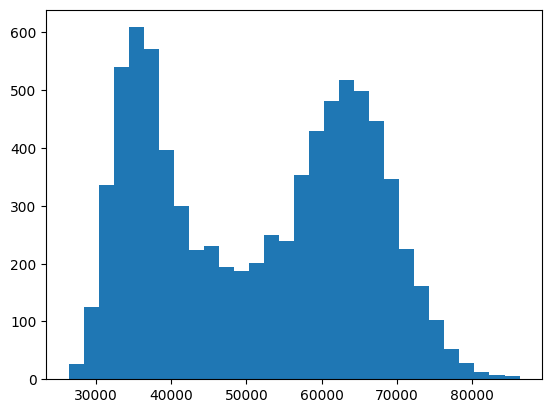

In [445]:
pixel_sums = []
for img in imgs1:
    pixel_sum = pyt.sum_pixel_values(img, grid_positions1, [9,9], window_size=3)
    pixel_sums.append(pixel_sum)
    
plt.hist(np.array(pixel_sums).flatten(), bins=30)
rn_threshold = 50000

In [1203]:
local_cam.relinquish_camera()

{'ok': True, 'relinquished': True}

---

In [1547]:
import zmq
import zmq.asyncio
import pickle as pkl
import asyncio

class RearrangementNode:
    def __init__(self, address="tcp://10.59.3.1:2222", timeout_ms=2000):
        self.context = zmq.asyncio.Context()
        self.socket = self.context.socket(zmq.REQ)
        self.socket.connect(address)

    async def initialise(self, terms1, terms2, grid_positions, threshold, d0, fps, roi=[50, 70, 384, 384]):
        """Sends metadata in the header and the raw bytes in the payload."""
        
        w1, theta1, x1, y1, arr_shape1 = terms1
        w2, theta2, x2, y2, arr_shape2 = terms2

        data1 = np.array([w1.get(), theta1.get(), x1.get(), y1.get()])
        data2 = np.array([w2.get(), theta2.get(), x2.get(), y2.get()])

        header = {
            "cmd": "INITIALISE",
            "dtype1": str(data1.dtype),
            "dtype2": str(data2.dtype),
            "shape1": data1.shape,
            "shape2": data2.shape,
            "array_shape1": arr_shape1,
            "array_shape2": arr_shape2,
            "d0": d0,
            "fps": fps,
            "threshold": threshold,
            "grid_positions": grid_positions,
            "roi": roi
        }

        await self.socket.send_multipart([pkl.dumps(header), data1, data2], copy=False)
        reply = await self.socket.recv_string()
        print(reply)

    async def arm_rearrangement(self):
        """Sends a simple command with no array payload."""
        header = {"cmd": "ARM_REARRANGEMENT"}
        await self.socket.send_multipart([pkl.dumps(header)])

        print("ARM command sent...")
        
        parts = await self.socket.recv_multipart()
        reply_header = pkl.loads(parts[0])
        img0 = np.frombuffer(parts[1], dtype=reply_header["img0_dtype"]).reshape(reply_header["img0_shape"])
        img1 = np.frombuffer(parts[2], dtype=reply_header["img1_dtype"]).reshape(reply_header["img1_shape"])
        debug_sequence = np.frombuffer(parts[3], dtype=reply_header["debug_sequence_dtype"]).reshape(reply_header["debug_sequence_shape"])
        occ_mask = np.frombuffer(parts[4], dtype=reply_header["occ_mask_dtype"]).reshape(reply_header["occ_mask_shape"])
        return img0, img1, debug_sequence, occ_mask

    async def test(self):
        """Sends a simple command with no array payload."""
        header = {"cmd": "TEST"}
        await self.socket.send_multipart([pkl.dumps(header)])

        print("TEST command sent...")
        
        parts = await self.socket.recv_multipart()
        reply_header = pkl.loads(parts[0])
        img0 = np.frombuffer(parts[1], dtype=reply_header["img0_dtype"]).reshape(reply_header["img0_shape"])
        img1 = np.frombuffer(parts[2], dtype=reply_header["img1_dtype"]).reshape(reply_header["img1_shape"])
        
        print("Images obtained from server.")
        return img0, img1

    async def shutdown(self):
        """Sends a shutdown command to the server."""
        header = {"cmd": "SHUTDOWN"}
        await self.socket.send_multipart([pkl.dumps(header)])
        reply = await self.socket.recv_string()
        print(reply)

In [1548]:
RN = RearrangementNode()

In [1549]:
exp.set_motmaster_experiment("RbTweezerBasic2026_ImagingSurvivalMeasurement")
exp.set_iterations(1)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [1575]:
await RN.initialise(terms1, terms2, grid_positions1, 50000, d0=0.25, fps=1/(1e-6), roi=[50, 70, 384, 384])

{"status": "success", "msg": "Rearrangement node initialised."}


In [1583]:
N_iterations = 100
imgs = []
err_indices = []
debug_sequences = []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(RN.arm_rearrangement())
    sleep(1)
    exp.start_motmaster_experiment({"tImgCool": 0.00, "tImgCoolVVA": 0.43})
    img0, img1, debug_sequence, occ_mask = await rearrangement_task
    print("Images acquired from rearrangement node.")
    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs.append([img0, img1])
    debug_sequences.append(debug_sequence)

Running experiment iteration 1 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment iteration 2 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment iteration 3 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment iteration 4 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment iteration 5 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment iteration 6 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment iteration 7 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment iteration 8 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment iteration 9 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment iteration 10 / 100
ARM command sent...
Images acquired from rearrangement node.
Running experiment 

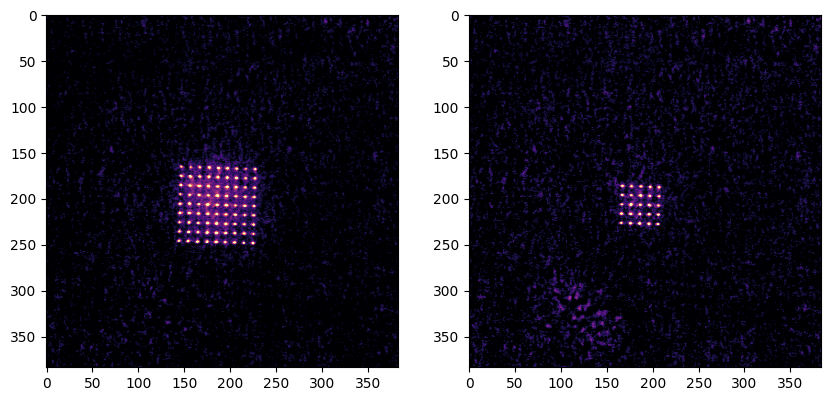

In [1594]:
tot_imgs = np.array(imgs)
imgs1 = tot_imgs[:, 0]
imgs2 = tot_imgs[:, 1]
imgs1_mean = imgs1.mean(axis=0) - img_bg
imgs2_mean = imgs2.mean(axis=0) - img_bg

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imgs1_mean, cmap='magma', vmin=imgs1_mean.mean(), vmax=imgs1_mean.max()*0.5)
axs[1].imshow(imgs2_mean, cmap='magma', vmin=imgs2_mean.mean(), vmax=imgs2_mean.max()*0.5)

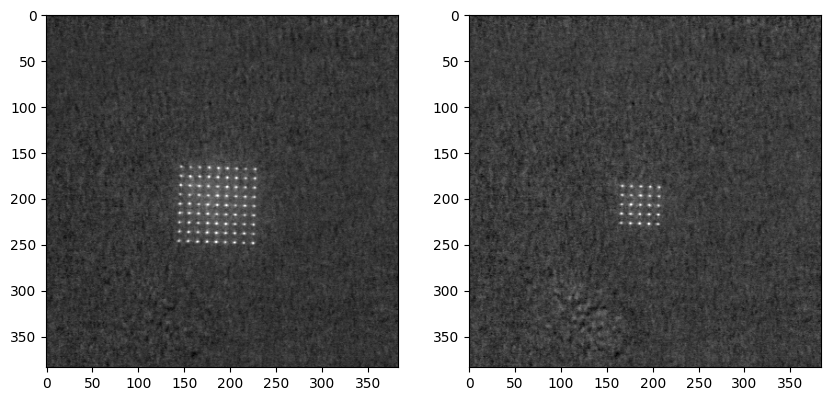

In [1584]:
tot_imgs = np.array(imgs)
imgs1 = tot_imgs[:, 0]
imgs2 = tot_imgs[:, 1]
imgs1_mean = imgs1.mean(axis=0) - img_bg
imgs2_mean = imgs2.mean(axis=0) - img_bg

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imgs1_mean, cmap='gray', vmax=imgs1_mean.max()*0.8)
axs[1].imshow(imgs2_mean, cmap='gray', vmax=imgs2_mean.max()*0.8)

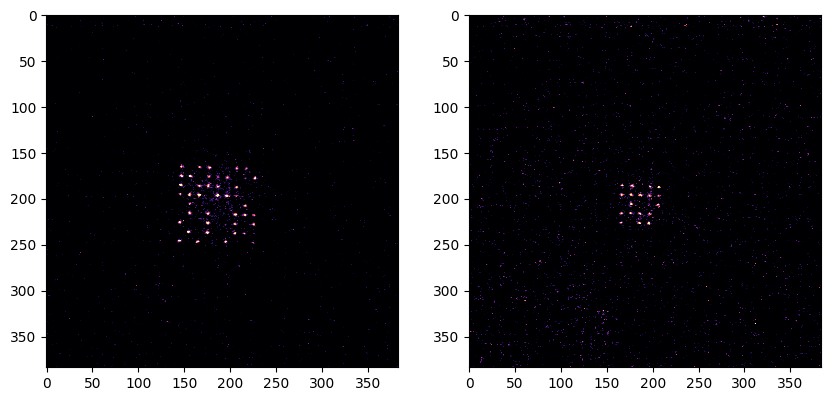

In [1582]:
n = 0
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imgs1[n] - img_bg, cmap='magma', vmin=(imgs1[n] - img_bg).max()*0.1, vmax=(imgs1[n] - img_bg).max()*0.4)
axs[1].imshow(imgs2[n] - img_bg, cmap='magma', vmin=(imgs2[n] - img_bg).max()*0.1, vmax=(imgs2[n] - img_bg).max()*0.4)

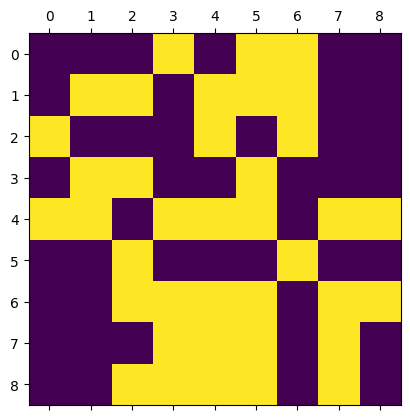

In [1271]:
plt.matshow(np.fliplr(occ_mask.reshape(9, 9)))

---

In [1488]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

debug_sequences_array = debug_sequences[0]

# You can reduce these if rendering is too slow
Nx_pad = 2048 * 2
Ny_pad = 2048 * 2

fig, ax = plt.subplots(figsize=(6, 6))

# Initialize with first frame
pm0 = debug_sequences_array[0]
field0 = PM.simulate_focal_plane(pm0, Nx_pad=Nx_pad, Ny_pad=Ny_pad, show=False)
I0 = np.abs(field0) ** 2
norm0 = I0 / I0.max()

im = ax.imshow(
    norm0,
    extent=[-PM.Nx * PM.dx_f, PM.Nx * PM.dx_f, -PM.Ny * PM.dy_f, PM.Ny * PM.dy_f],
    cmap="viridis",
    animated=True
)
ax.set_xlim(-80, 80)
ax.set_ylim(-80, 80)
title = ax.set_title("norm_intensity frame 0")

def update(i):
    pm = debug_sequences_array[i]
    field_foc = PM.simulate_focal_plane(pm, Nx_pad=Nx_pad, Ny_pad=Ny_pad, show=False)
    I_foc = np.abs(field_foc) ** 2
    norm_intensity = I_foc / I_foc.max()

    im.set_data(norm_intensity)
    title.set_text(f"norm_intensity frame {i}")
    return im, title

anim = FuncAnimation(fig, update, frames=len(debug_sequences_array), interval=200, blit=False)
plt.close(fig)

HTML(anim.to_jshtml())


---

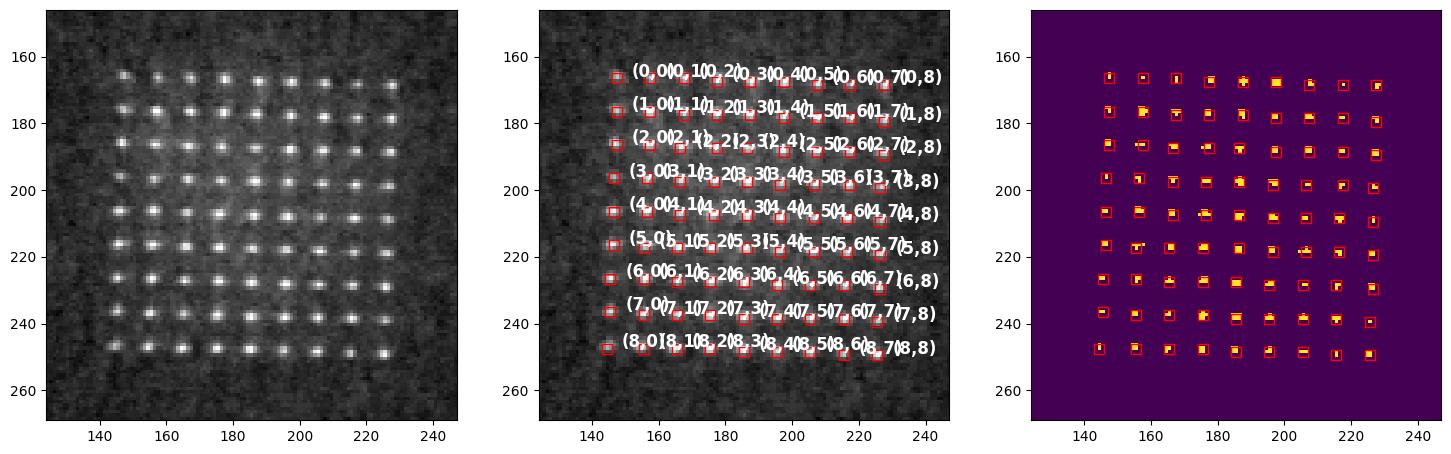

Trap (0, 0) Loading Probability : 51.0 %
Trap (0, 1) Loading Probability : 46.0 %
Trap (0, 2) Loading Probability : 52.0 %
Trap (0, 3) Loading Probability : 61.0 %
Trap (0, 4) Loading Probability : 60.0 %
Trap (0, 5) Loading Probability : 60.0 %
Trap (0, 6) Loading Probability : 51.0 %
Trap (0, 7) Loading Probability : 46.0 %
Trap (0, 8) Loading Probability : 56.99999999999999 %
Trap (1, 0) Loading Probability : 55.00000000000001 %
Trap (1, 1) Loading Probability : 65.0 %
Trap (1, 2) Loading Probability : 56.99999999999999 %
Trap (1, 3) Loading Probability : 62.0 %
Trap (1, 4) Loading Probability : 60.0 %
Trap (1, 5) Loading Probability : 52.0 %
Trap (1, 6) Loading Probability : 60.0 %
Trap (1, 7) Loading Probability : 49.0 %
Trap (1, 8) Loading Probability : 57.99999999999999 %
Trap (2, 0) Loading Probability : 60.0 %
Trap (2, 1) Loading Probability : 56.00000000000001 %
Trap (2, 2) Loading Probability : 57.99999999999999 %
Trap (2, 3) Loading Probability : 53.0 %
Trap (2, 4) Loading 

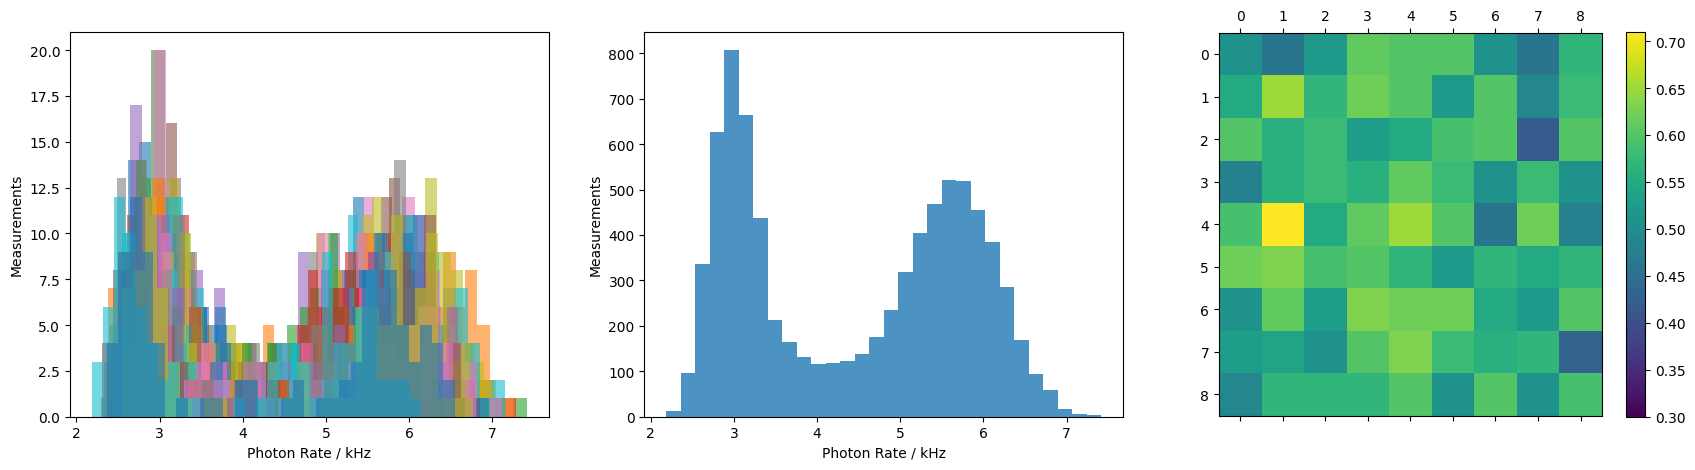

In [1585]:
pyt.visualize_results(imgs1_mean, grid_positions1, margin=20, window_size=window, threshold=detection_threshold)
photon_rates, loading_probabilities, _ = texp.get_array_loading_probability(imgs1, grid_positions1, [9,9], threshold=4, window_size=window, binning=30)

print(f"Standard Deviation = {np.std(loading_probabilities) / loading_probabilities.mean()*100} %")
print(f"Average Loading Prob = {loading_probabilities.mean()*100} %")

Looking for trap sites...
5x5 array detected.


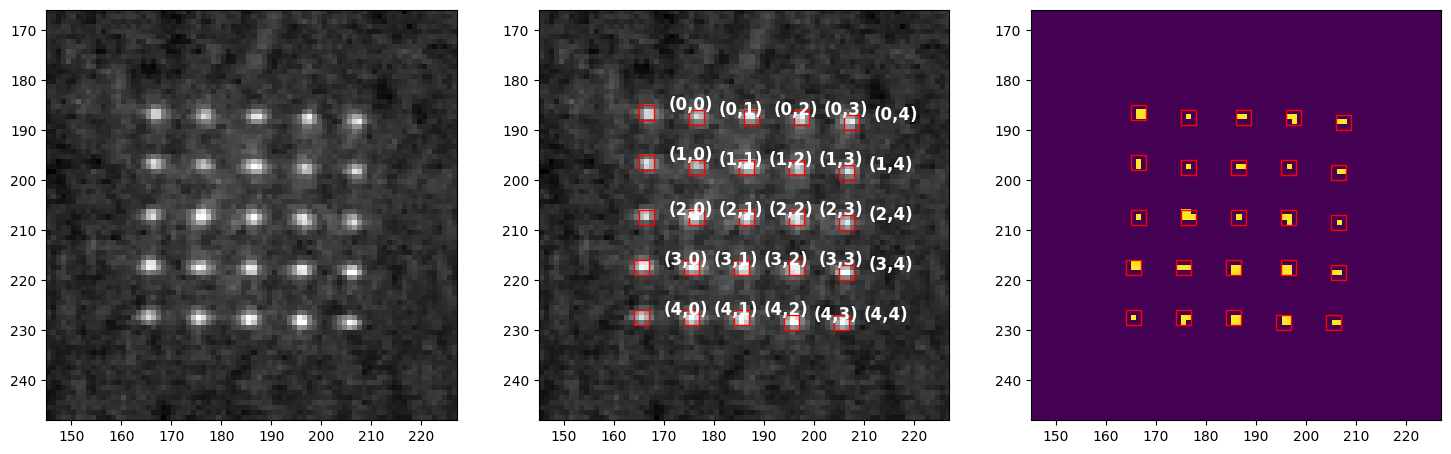

Trap (0, 0) Loading Probability : 73.0 %
Trap (0, 1) Loading Probability : 67.0 %
Trap (0, 2) Loading Probability : 74.0 %
Trap (0, 3) Loading Probability : 71.0 %
Trap (0, 4) Loading Probability : 77.0 %
Trap (1, 0) Loading Probability : 71.0 %
Trap (1, 1) Loading Probability : 72.0 %
Trap (1, 2) Loading Probability : 79.0 %
Trap (1, 3) Loading Probability : 71.0 %
Trap (1, 4) Loading Probability : 74.0 %
Trap (2, 0) Loading Probability : 77.0 %
Trap (2, 1) Loading Probability : 79.0 %
Trap (2, 2) Loading Probability : 73.0 %
Trap (2, 3) Loading Probability : 77.0 %
Trap (2, 4) Loading Probability : 71.0 %
Trap (3, 0) Loading Probability : 81.0 %
Trap (3, 1) Loading Probability : 82.0 %
Trap (3, 2) Loading Probability : 73.0 %
Trap (3, 3) Loading Probability : 78.0 %
Trap (3, 4) Loading Probability : 82.0 %
Trap (4, 0) Loading Probability : 69.0 %
Trap (4, 1) Loading Probability : 78.0 %
Trap (4, 2) Loading Probability : 75.0 %
Trap (4, 3) Loading Probability : 78.0 %
Trap (4, 4) Load

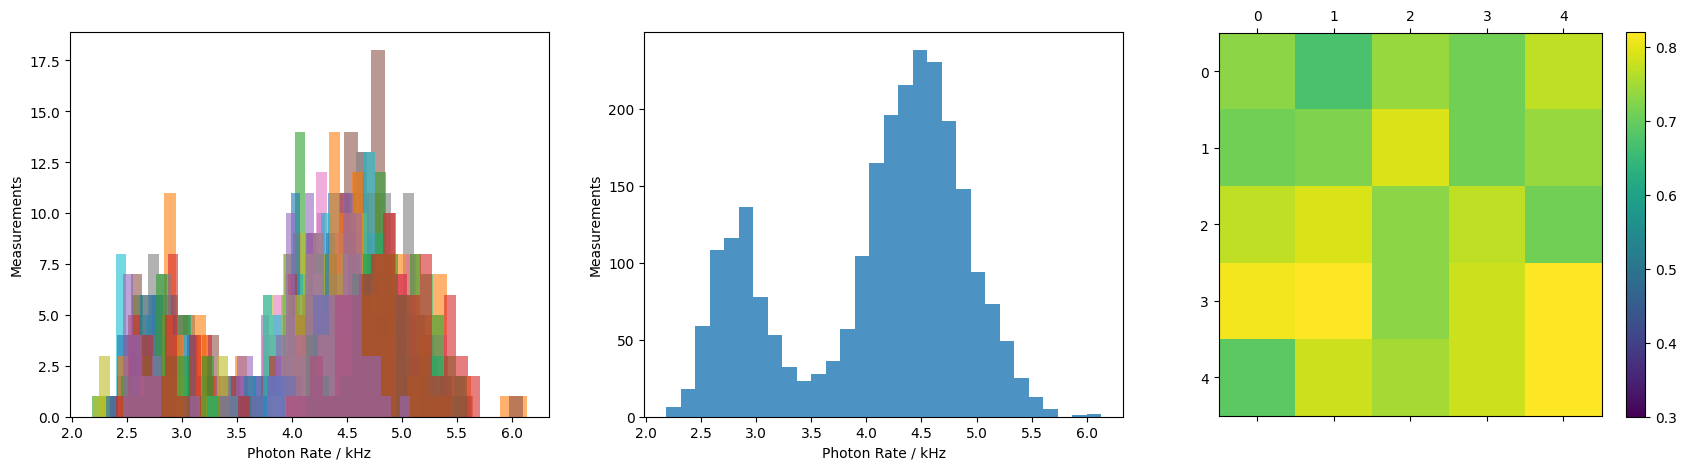

In [1586]:
grid_positions2, detection_threshold = pyt.detect_trap_sites(imgs2_mean, [5,5], detection_step=100)
pyt.visualize_results(imgs2_mean, grid_positions2, margin=20, window_size=window, threshold=detection_threshold)
photon_rates, loading_probabilities, _ = texp.get_array_loading_probability(imgs2, grid_positions2, [5,5], threshold=3.4, window_size=window, binning=30)

print(f"Standard Deviation = {np.std(loading_probabilities) / loading_probabilities.mean()*100} %")
print(f"Average Loading Prob = {loading_probabilities.mean()*100} %")

---

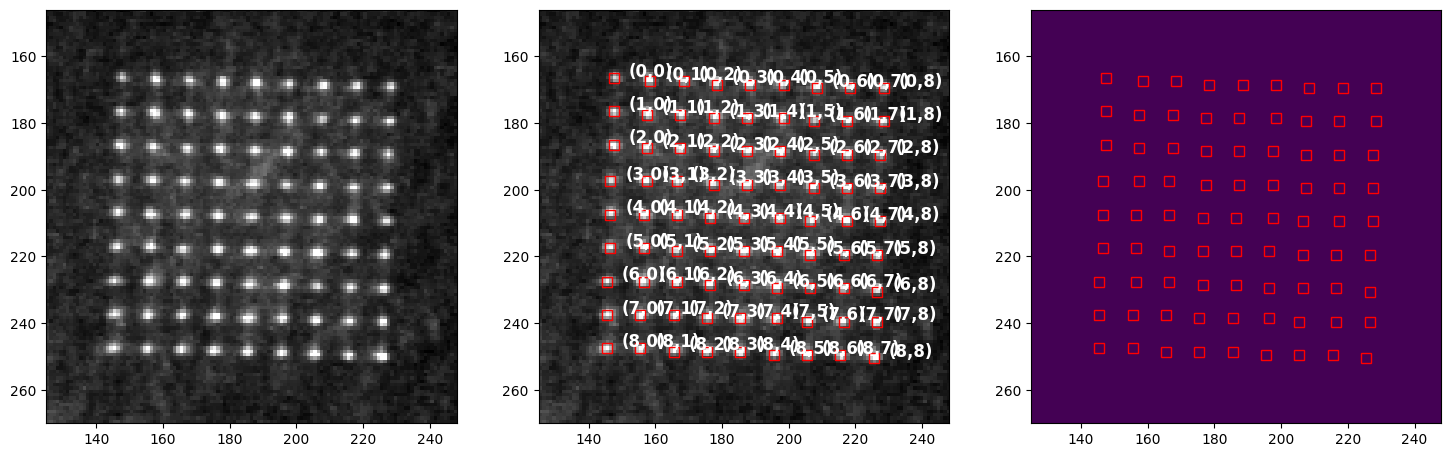

Trap (0, 0) Loading Probability : 46.0 %
Trap (0, 1) Loading Probability : 57.99999999999999 %
Trap (0, 2) Loading Probability : 45.0 %
Trap (0, 3) Loading Probability : 60.0 %
Trap (0, 4) Loading Probability : 61.0 %
Trap (0, 5) Loading Probability : 47.0 %
Trap (0, 6) Loading Probability : 53.0 %
Trap (0, 7) Loading Probability : 56.99999999999999 %
Trap (0, 8) Loading Probability : 52.0 %
Trap (1, 0) Loading Probability : 46.0 %
Trap (1, 1) Loading Probability : 64.0 %
Trap (1, 2) Loading Probability : 46.0 %
Trap (1, 3) Loading Probability : 54.0 %
Trap (1, 4) Loading Probability : 60.0 %
Trap (1, 5) Loading Probability : 56.00000000000001 %
Trap (1, 6) Loading Probability : 43.0 %
Trap (1, 7) Loading Probability : 49.0 %
Trap (1, 8) Loading Probability : 50.0 %
Trap (2, 0) Loading Probability : 57.99999999999999 %
Trap (2, 1) Loading Probability : 55.00000000000001 %
Trap (2, 2) Loading Probability : 52.0 %
Trap (2, 3) Loading Probability : 56.00000000000001 %
Trap (2, 4) Loading 

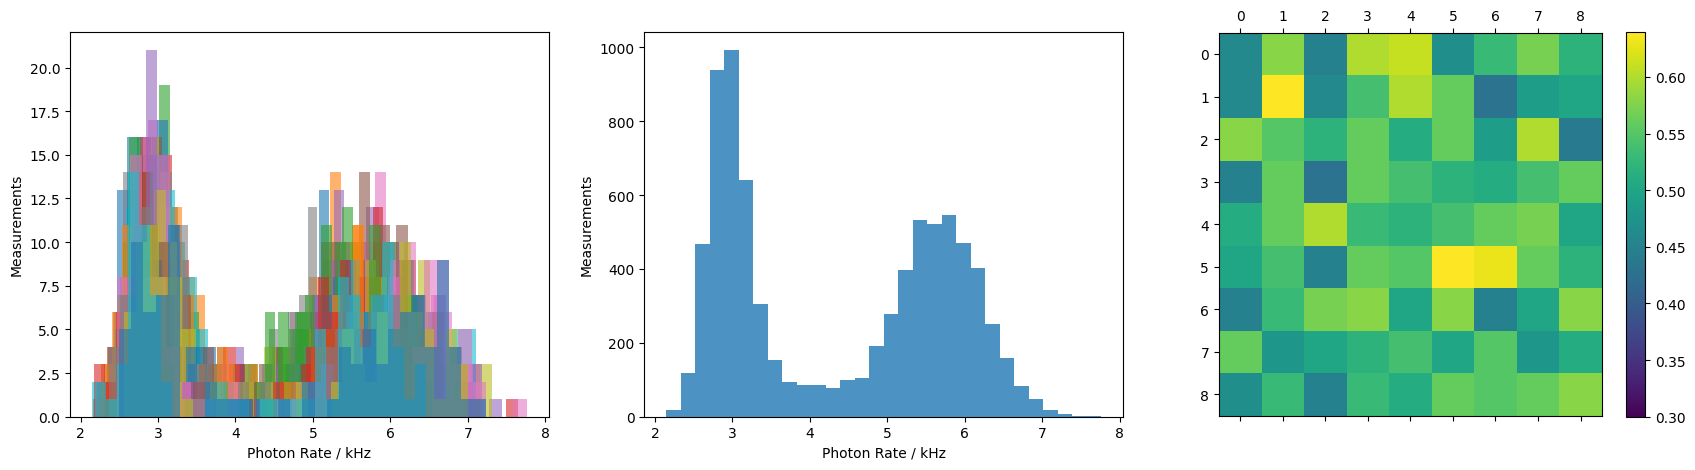

In [ ]:
pyt.visualize_results(imgs1_mean, grid_positions1, margin=20, window_size=window, threshold=detection_threshold)
photon_rates, loading_probabilities, _ = texp.get_array_loading_probability(imgs1, grid_positions1, [9,9], threshold=4., window_size=window, binning=30)

print(f"Loading Threshold = {threshold:.6f} kHz")
print(f"Standard Deviation = {np.std(loading_probabilities) / loading_probabilities.mean()*100} %")
print(f"Average Loading Prob = {loading_probabilities.mean()*100} %")

Looking for trap sites...
6x6 array detected.


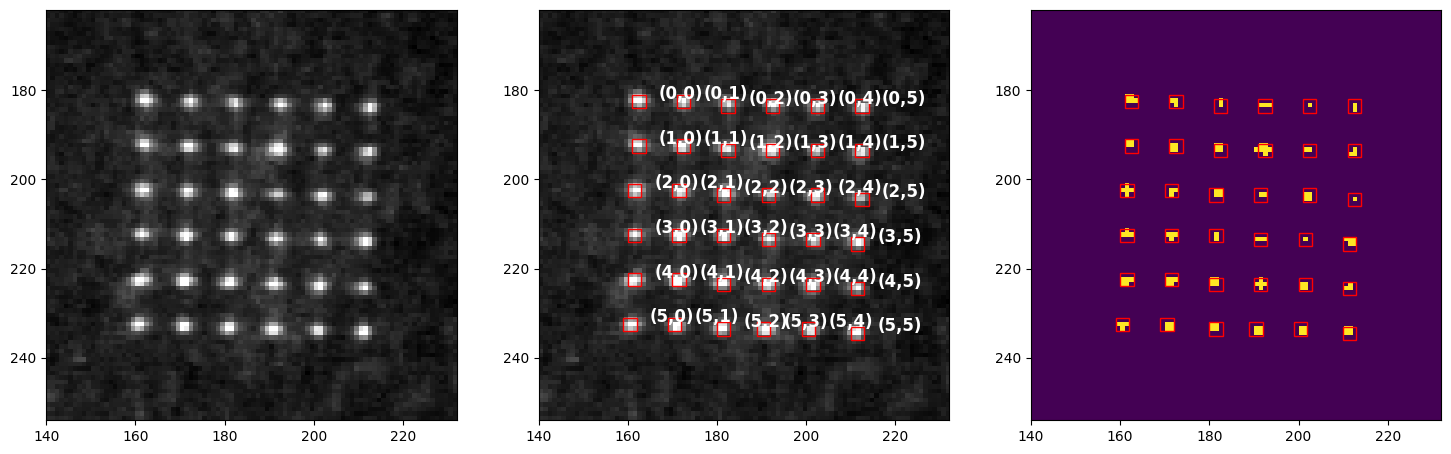

Trap (0, 0) Loading Probability : 82.82828282828282 %
Trap (0, 1) Loading Probability : 70.70707070707071 %
Trap (0, 2) Loading Probability : 68.68686868686868 %
Trap (0, 3) Loading Probability : 78.78787878787878 %
Trap (0, 4) Loading Probability : 68.68686868686868 %
Trap (0, 5) Loading Probability : 80.8080808080808 %
Trap (1, 0) Loading Probability : 82.82828282828282 %
Trap (1, 1) Loading Probability : 80.8080808080808 %
Trap (1, 2) Loading Probability : 71.71717171717171 %
Trap (1, 3) Loading Probability : 88.88888888888889 %
Trap (1, 4) Loading Probability : 75.75757575757575 %
Trap (1, 5) Loading Probability : 76.76767676767676 %
Trap (2, 0) Loading Probability : 81.81818181818183 %
Trap (2, 1) Loading Probability : 79.7979797979798 %
Trap (2, 2) Loading Probability : 82.82828282828282 %
Trap (2, 3) Loading Probability : 68.68686868686868 %
Trap (2, 4) Loading Probability : 83.83838383838383 %
Trap (2, 5) Loading Probability : 73.73737373737373 %
Trap (3, 0) Loading Probability

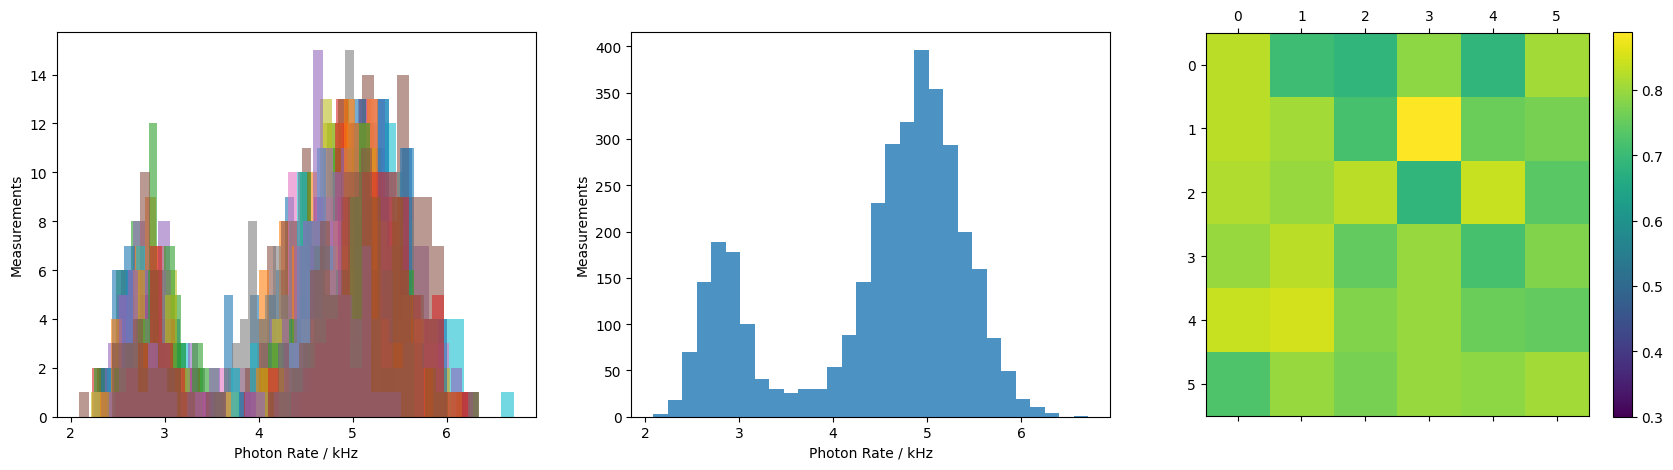

In [ ]:
grid_positions2, detection_threshold = pyt.detect_trap_sites(imgs2_mean, [6,6], detection_step=100)
pyt.visualize_results(imgs2_mean, grid_positions2, margin=20, window_size=window, threshold=detection_threshold)
photon_rates, loading_probabilities, _ = texp.get_array_loading_probability(imgs2_filtered, grid_positions2, [6,6], threshold=3.5, window_size=window, binning=30)

print(f"Loading Threshold = {threshold:.6f} kHz")
print(f"Standard Deviation = {np.std(loading_probabilities) / loading_probabilities.mean()*100} %")
print(f"Average Loading Prob = {loading_probabilities.mean()*100} %")

In [354]:
# Make a numpy array which contains 10 2D images, each of shape (384, 384)
image_array = np.random.rand(10, 384, 384)
image_array.shape

(10, 384, 384)

In [366]:
pm_sequence = np.array([pm_init_uint8, pm_init_uint8, pm_init_uint8, np.zeros_like(pm_init_uint8)])
SLM.run_sequence(pm_sequence, fps=1)

{'status': 'success', 'msg': 'Sequence completed successfully.'}

In [1587]:
local_cam.close()